# 03 — Feature Engineering

Build the feature matrix (own-asset + cross-asset OFI) and the target variable.
Visualise feature correlations and check for look-ahead bias.

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath('..'))

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from config import TICKERS, TARGET_ASSETS, SIGNAL_ASSET, OFI_HORIZONS, DEFAULT_FWD_HORIZON
from src.data_loader import load_processed
from src.features import prepare_dataset, build_target

sns.set_style('whitegrid')
%matplotlib inline

## 3.1 Load data

In [2]:
panel = load_processed('panel')
ofi_df = load_processed('ofi_all')

print(f"Panel shape: {panel.shape}")
print(f"OFI shape:   {ofi_df.shape}")

Panel shape: (98625, 25)
OFI shape:   (98625, 25)


## 3.2 Feature matrix for Bank Nifty (primary target)

In [3]:
target = 'BANKNIFTY'
close = panel[target]['close']

X_full, y = prepare_dataset(ofi_df, close, target, feature_set='full')
X_own, _  = prepare_dataset(ofi_df, close, target, feature_set='own')

print(f"Full features: {X_full.shape}  ({list(X_full.columns)})")
print(f"Own features:  {X_own.shape}  ({list(X_own.columns)})")
print(f"Target (y):    {len(y)} observations")
print(f"\ny stats: mean={y.mean():.6f}, std={y.std():.6f}, min={y.min():.6f}, max={y.max():.6f}")

Full features: (98620, 10)  (['BANKNIFTY_ofi_1', 'BANKNIFTY_ofi_5', 'BANKNIFTY_ofi_15', 'BANKNIFTY_ofi_30', 'BANKNIFTY_ofi_60', 'NIFTY_ofi_1', 'NIFTY_ofi_5', 'NIFTY_ofi_15', 'NIFTY_ofi_30', 'NIFTY_ofi_60'])
Own features:  (98620, 5)  (['BANKNIFTY_ofi_1', 'BANKNIFTY_ofi_5', 'BANKNIFTY_ofi_15', 'BANKNIFTY_ofi_30', 'BANKNIFTY_ofi_60'])
Target (y):    98620 observations

y stats: mean=-0.000016, std=0.001669, min=-0.008362, max=0.007039


## 3.3 Feature correlation heatmap

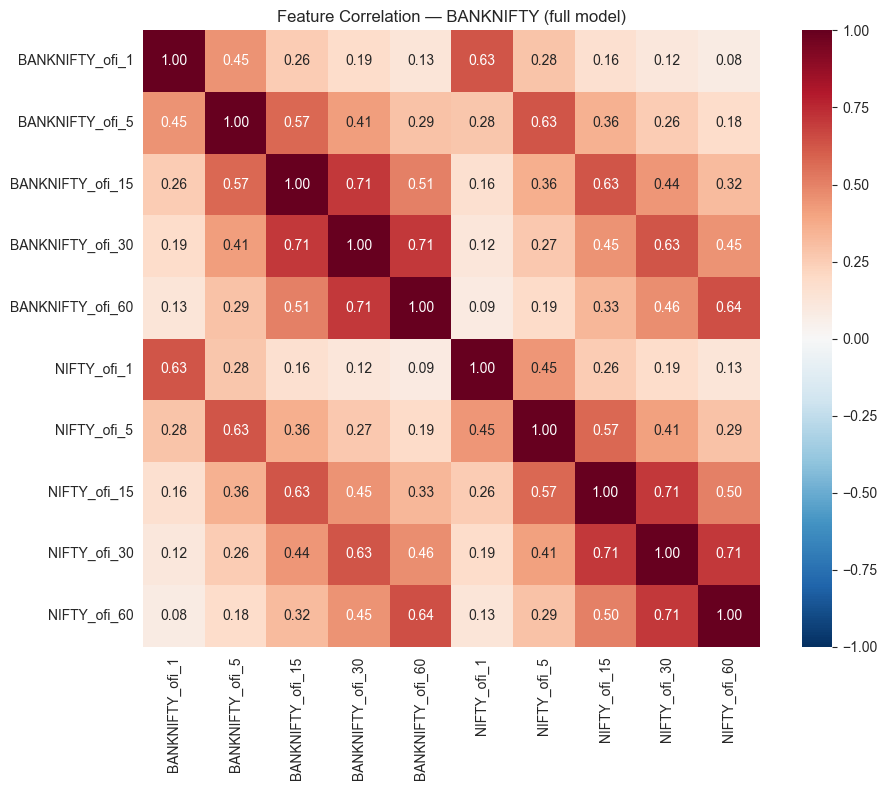


Note: high correlation between adjacent horizons is expected — this is why Ridge is preferred over OLS.


In [4]:
fig, ax = plt.subplots(figsize=(10, 8))

corr = X_full.corr()
sns.heatmap(corr, annot=True, fmt='.2f', cmap='RdBu_r', center=0,
            ax=ax, vmin=-1, vmax=1, square=True)
ax.set_title(f'Feature Correlation — {target} (full model)')

plt.tight_layout()
plt.savefig('../outputs/figures/feature_correlation_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()

print("\nNote: high correlation between adjacent horizons is expected — this is why Ridge is preferred over OLS.")

## 3.4 Feature–target correlations

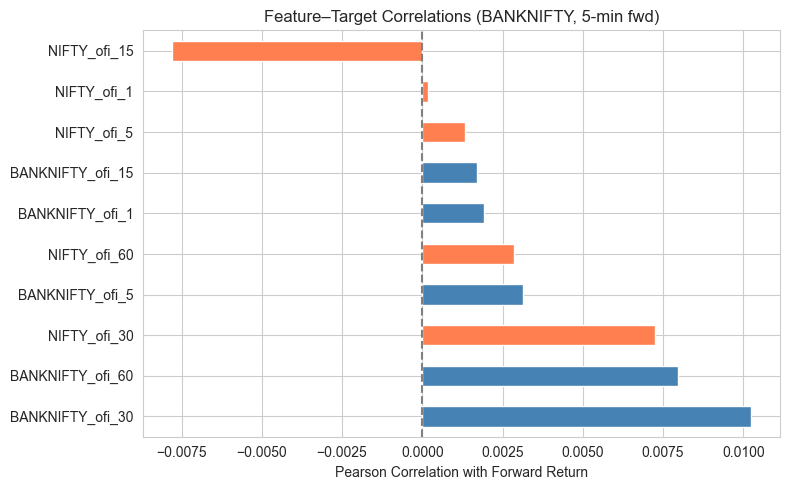

In [5]:
correlations = X_full.corrwith(y).sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(8, 5))
correlations.plot(kind='barh', ax=ax, color=['steelblue' if 'BANKNIFTY' in c else 'coral' for c in correlations.index])
ax.set_xlabel('Pearson Correlation with Forward Return')
ax.set_title(f'Feature–Target Correlations ({target}, {DEFAULT_FWD_HORIZON}-min fwd)')
ax.axvline(0, color='gray', linestyle='--')

plt.tight_layout()
plt.savefig('../outputs/figures/feature_target_correlations.png', dpi=150, bbox_inches='tight')
plt.show()

## 3.5 Look-ahead bias check

All OFI features use **trailing** rolling windows (only past data).
The target is a **forward** return. Let's verify no future data leaks in.

In [6]:
# Sanity check: shuffle the target and re-check correlation
y_shuffled = y.sample(frac=1, random_state=42)
y_shuffled.index = y.index

shuffled_corr = X_full.corrwith(y_shuffled).abs().mean()
real_corr = X_full.corrwith(y).abs().mean()

print(f"Mean |corr| with real target:     {real_corr:.6f}")
print(f"Mean |corr| with shuffled target: {shuffled_corr:.6f}")
print("\nIf shuffled is near zero and real is meaningfully larger → no look-ahead bias.")

Mean |corr| with real target:     0.004442
Mean |corr| with shuffled target: 0.002269

If shuffled is near zero and real is meaningfully larger → no look-ahead bias.


## 3.6 Summary for all target assets

In [7]:
for t in TARGET_ASSETS:
    close_t = panel[t]['close']
    X_f, y_t = prepare_dataset(ofi_df, close_t, t, feature_set='full')
    best_feat = X_f.corrwith(y_t).abs().idxmax()
    best_corr = X_f.corrwith(y_t).abs().max()
    print(f"{t:12s}  n={len(y_t):>7,}  best_feature={best_feat}  corr={best_corr:.4f}")

BANKNIFTY     n= 98,620  best_feature=BANKNIFTY_ofi_30  corr=0.0102
HDFCBANK      n= 98,620  best_feature=HDFCBANK_ofi_60  corr=0.0148
RELIANCE      n= 98,620  best_feature=RELIANCE_ofi_30  corr=0.0145
INFY          n= 98,620  best_feature=INFY_ofi_60  corr=0.0074
